# 0. Carga de datos


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 0.1. Ventas

In [2]:
# Cargar datos
path_ventas = "datos/Ventas por Cliente/ventas_con_precio_lista_y_descuentos_2025_2026.csv"
ventas = pd.read_csv(path_ventas)
print("Ventas - Filas:", ventas.shape[0])
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_27004/3745035006.py:3: DtypeWarning: Columns (0: dscto_volumen, 1: ids_descuento_volumen) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


Ventas - Filas: 10596574


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Factura Venta',
       'Factura Kilos', 'Kilo Real', 'Kilos Nc', 'Monto Nc', 'Monto Real',
       'Precio', 'venta_id', 'Zona', 'Distrito', 'Precio_Lista', 'dscto_base',
       'id_descuento_base', 'dscto_volumen', 'ids_descuento_volumen',
       'dscto_binario', 'id_descuento_binario', 'carta_impacto',
       'id_descuento_carta_impacto'],
      dtype='str')

In [4]:
ventas["Nombre Consolidado"].unique()
## Filtrar solo los canales relevantes
# - Cobertura
# - Volumen Cobertura
# - Mayoristas Cadenas
# - Mayorista B Volumen
# - Otros Mayoristas
# - Horeca Volumen
# - Otros Horeca
# Pero llevan estos nombres en el df:
# <StringArray>
# [          'COBERTURA',        'OTROS HORECA',   'VOLUMEN COBERTURA',
#  'HR ACUERDOS COMERC.', 'MAYORISTA B VOLUMEN',      'HORECA VOLUMEN',
#   'HR CUENTAS CLAVES.',    'OTROS MAYORISTAS',  'MAYORISTAS CADENAS',
#          'CHILECOMPRA']
# Length: 10, dtype: str
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    "MAYORISTAS CADENAS",
    "MAYORISTA B VOLUMEN",
    "OTROS MAYORISTAS",
    "HORECA VOLUMEN",
    "OTROS HORECA",
]
ventas = ventas[ventas["Nombre Consolidado"].isin(canales_relevantes)]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 10364933


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Distrito,Precio_Lista,dscto_base,id_descuento_base,dscto_volumen,ids_descuento_volumen,dscto_binario,id_descuento_binario,carta_impacto,id_descuento_carta_impacto
0,2025,1,CB,ZV01,2025-01-02,1145633,NaN,32,COBERTURA,SALAMES,...,PUNTA ARENAS,11538.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,HR,ZV01,2025-01-03,43790,NaN,55,HORECA VOLUMEN,MORTADELAS,...,SANTIAGO HORECA PAP,2715.0,-3.0,2352.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,HR,ZV01,2025-01-03,1227049,NaN,37,OTROS HORECA,VIENESAS,...,SANTIAGO HORECA PAP,2722.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,CB,ZV01,2025-01-02,1174760,NaN,32,COBERTURA,HAMBURGUESAS,...,NaN,5171.0,-12.5,2372.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,HR,ZV01,2025-01-03,1015869,NaN,55,HORECA VOLUMEN,PARRILLEROS,...,SANTIAGO HORECA PAP,3232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Filtrar columnas relevantes
cols_relevantes_ventas = [
    # Id Cliente
    "Cod Cliente", 
    # Info Canal
    "Cod Canal Comercial", "Cod Consolidado", "Zona",
    # Fecha real de la venta
    "Fecha Factura",
    # Id Producto
    "Cod SKU",
    # Info Producto
    "Nombre SKU",
    # Monto Venta
    "Monto Real",
    # Cantidad Venta
    "Kilo Real",
    # Precio real (por kg)
    "Precio",
    # Precio Lista
    "Precio_Lista"
    ]
ventas = ventas[cols_relevantes_ventas]
ventas.head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.0,10860.000000,11538.0
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.0,2634.000000,2715.0
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.4,2722.006579,2722.0
3,1174760,CB,32,NaN,2025-01-02,3991,HAMBURGUESA GRILL TASTE LP 24x100 GR.,10862,2.4,4525.833333,5171.0
4,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.8,3135.000000,3232.0


In [6]:
# Contar nans por columna
nans_por_columna = ventas.isna().sum()
print("Nans por columna:")
print(nans_por_columna)

Nans por columna:
Cod Cliente                 0
Cod Canal Comercial       199
Cod Consolidado             0
Zona                   512593
Fecha Factura               0
Cod SKU                     0
Nombre SKU                  0
Monto Real                  0
Kilo Real                   0
Precio                      6
Precio_Lista              151
dtype: int64


In [7]:
ventas[ventas["Cod Canal Comercial"].isna()].head()

,Cod Cliente,Cod Canal Comercial,Cod Consolidado,Zona,Fecha Factura,Cod SKU,Nombre SKU,Monto Real,Kilo Real,Precio,Precio_Lista
9814678,1196497,NaN,37,NaN,2025-12-01,3581,VIENESA SIN PIEL 10x760 GR LP,32323,7.6,4253.026316,6579.0
9817286,1236846,NaN,37,NaN,2025-12-01,1434,CHORIZO PARRILLERO SJ 400 GR,163548,44.0,3717.000000,5750.0
9818961,1236846,NaN,37,NaN,2025-12-01,1434,CHORIZO PARRILLERO SJ 400 GR,29736,8.0,3717.000000,5750.0
9824081,1236859,NaN,32,SUR 2,2025-12-02,915,VIENESA SUREÑA 12x250 GR SJ,9695,3.0,3231.666667,5000.0
9824082,1236859,NaN,32,SUR 2,2025-12-02,3313,MORTADELA JAMONADA CENTENARIO LP,11867,3.0,3955.666667,7200.0


In [8]:
# Indicar cuantas filas y columnas tiene el dataframe antes de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas antes de filtrar.")

# Filtrar datos con nans en alguna columna relevante
ventas = ventas.dropna(subset=cols_relevantes_ventas)

# Indicar cuantas filas y columnas tiene el dataframe después de filtrar
print(f"El dataframe tiene {ventas.shape[0]} filas y {ventas.shape[1]} columnas después de filtrar.")

El dataframe tiene 10364933 filas y 11 columnas antes de filtrar.
El dataframe tiene 9852085 filas y 11 columnas después de filtrar.


## 0.2. Maestro SKUs

In [9]:
# Cargar datos
path_maestro = "datos/Maestro Productos.xlsx"
maestro = pd.read_excel(path_maestro, header=2)
maestro.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [10]:
# Filtrar columnas relevantes
cols_relevantes_maestro = [
    # Id Producto
    "Material",
    # Info Producto
    "Texto breve de material",
    # Producto con peso cte?
    "Peso Var/Std",
    # Kg por Unidad
    "Neto"
]
maestro = maestro[cols_relevantes_maestro]
maestro["peso_variable"] = maestro["Peso Var/Std"] != "Peso Standard"
maestro.drop(columns="Peso Var/Std", inplace=True)
maestro.head()

,Material,Texto breve de material,Neto,peso_variable
0,20,ARROLLADO LOMO CON AJI SJ,3.172,True
1,21,ARROLLADO LOMO CORTADO SJ,2.000,False
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,0.250,False
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,0.250,False
4,27,ARROLLADO LOMO SIN AJI SJ,3.268,True


# 0.3 Zonales

In [11]:
path_info_zonales = "datos/Clientes - Zonales.xlsx"
zonales = pd.read_excel(path_info_zonales)
zonales.head()

,Id cliente,REGIONES
0,1194043,RANCAGUA
1,1155918,RANCAGUA
2,1090050,RANCAGUA
3,1203751,RANCAGUA
4,1231602,IQUIQUE


In [12]:
zonales.columns

Index(['Id cliente', 'REGIONES'], dtype='str')

# 1. Cruces de bases y filtros preliminares


In [13]:
# Normalizar nombres de columnas y derivar año/mes desde Fecha Factura
ventas.columns = [
    "cod_cliente",
    "cod_canal_comercial", "cod_consolidado", "zona",
    "fecha_factura",
    "cod_sku",
    "nombre_sku",
    "monto_real",
    "kilo_real",
    "precio_real",
    "precio_lista"
]
ventas["fecha_factura"] = pd.to_datetime(ventas["fecha_factura"], errors="coerce")
ventas = ventas.dropna(subset=["fecha_factura"]).copy()
ventas["año_factura"] = ventas["fecha_factura"].dt.year.astype(int)
ventas["mes_factura"] = ventas["fecha_factura"].dt.month.astype(int)

maestro.columns = [
    "cod_sku",
    "texto_breve_material",
    "kg_por_unidad",
    "peso_variable"
]

In [14]:
# Agregar columna de kg_por_unidad a ventas
ventas = ventas.merge(maestro[["cod_sku", "kg_por_unidad", "peso_variable"]], on="cod_sku", how="left")

# Calcular cantidad en unidades
ventas["cantidad_unidades"] = ventas["kilo_real"] / ventas["kg_por_unidad"]
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,10860.000000,11538.0,2025,1,0.10,False,40.000000
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.000,2634.000000,2715.0,2025,1,3.00,False,4.000000
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.400,2722.006579,2722.0,2025,1,0.38,False,80.000000
3,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.800,3135.000000,3232.0,2025,1,0.80,False,6.000000
4,1015623,HR,37,SANTIAGO,2025-01-03,8210,JAMON ACARAM TRADICIONAL WIN,228385,36.425,6270.006863,6464.0,2025,1,4.41,True,8.259637


In [15]:
# Revisar que columnas con cantidad_unidades no entera sean las mismas que las que tienen peso_variable = True
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades"].isna() | np.isclose(ventas["cantidad_unidades"], np.round(ventas["cantidad_unidades"]), atol=1e-6, rtol=0)

ventas["peso_variable"] = ventas["peso_variable"].fillna(False)
ventas["cantidad_unidades_entera"] = ventas["cantidad_unidades_entera"].fillna(True)
ventas["inconsistencia"] = (ventas["peso_variable"] == False) & (ventas["cantidad_unidades_entera"] == False)

ventas["inconsistencia"].value_counts()

inconsistencia
False    9851841
True         244
Name: count, dtype: int64

In [16]:
# Ver columnas con inconsistencia
ventas[ventas["inconsistencia"]].head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
8131,1149632,HR,55,NORTE 1,2025-07-23,3313,MORTADELA JAMONADA CENTENARIO LP,13264,5.700,2327.017544,4654.0,2025,7,3.00,False,1.9000,False,True
142263,1202606,CB,54,SUR 1,2025-03-21,403,MORTADELA LISA MINI PZA 8X400 GR SJ,318,0.140,2271.428571,2343.0,2025,3,0.40,False,0.3500,False,True
156338,1198780,CB,32,SUR 3,2025-07-28,2272,PAPAS PRE-FRITAS SAN JORGE,107704,58.334,1846.333185,2308.0,2025,7,2.50,False,23.3336,False,True
163978,1198780,CB,32,SUR 3,2025-08-04,2272,PAPAS PRE-FRITAS SAN JORGE,221568,95.999,2308.024042,2308.0,2025,8,2.50,False,38.3996,False,True
188441,1091442,CB,54,SUR 1,2025-02-27,904,VIENESA PAVO 12X250 GR SJ,8530,2.999,2844.281427,2844.0,2025,2,0.25,False,11.9960,False,True


In [17]:
# Decidir que hacer con estas filas
# -> Redondear unidades a entero, dejar registro en un columna unidades_redondeadas (Bool)
ventas["cantidad_unidades"] = np.where(ventas["inconsistencia"], np.round(ventas["cantidad_unidades"]), ventas["cantidad_unidades"])
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,precio_lista,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,10860.000000,11538.0,2025,1,0.10,False,40.000000,True,False
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.000,2634.000000,2715.0,2025,1,3.00,False,4.000000,True,False
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.400,2722.006579,2722.0,2025,1,0.38,False,80.000000,True,False
3,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.800,3135.000000,3232.0,2025,1,0.80,False,6.000000,True,False
4,1015623,HR,37,SANTIAGO,2025-01-03,8210,JAMON ACARAM TRADICIONAL WIN,228385,36.425,6270.006863,6464.0,2025,1,4.41,True,8.259637,False,False


In [18]:
# Agregar zonal a ventas Index(['Id cliente', 'REGIONES'], dtype='str')
ventas = ventas.merge(zonales[["Id cliente", "REGIONES"]].rename(columns={"Id cliente": "cod_cliente", "REGIONES": "zonal"}), on="cod_cliente", how="left")

# 2. Análisis


In [19]:
# Filtrar ventas para tener sólo de unidades mayores a 0
ventas = ventas[ventas["cantidad_unidades"] > 0]

In [20]:
# Calcular precio por unidad en cada venta
ventas["precio_por_unidad"] = ventas["monto_real"] / ventas["cantidad_unidades"]
ventas["precio_lista_por_unidad"] = ventas["precio_lista"] * ventas["kg_por_unidad"]

ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,año_factura,mes_factura,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,10860.000000,...,2025,1,0.10,False,40.000000,True,False,PUNTA ARENAS,1086.000000,1153.80
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.000,2634.000000,...,2025,1,3.00,False,4.000000,True,False,SANTIAGO,7902.000000,8145.00
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.400,2722.006579,...,2025,1,0.38,False,80.000000,True,False,SANTIAGO,1034.362500,1034.36
3,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.800,3135.000000,...,2025,1,0.80,False,6.000000,True,False,SANTIAGO,2508.000000,2585.60
4,1015623,HR,37,SANTIAGO,2025-01-03,8210,JAMON ACARAM TRADICIONAL WIN,228385,36.425,6270.006863,...,2025,1,4.41,True,8.259637,False,False,SANTIAGO,27650.730268,28506.24


In [21]:
# Calcular precio promedio por unidad para cada SKU-mes-año usando Fecha Factura
precio_promedio_por_unidad = ventas.groupby(["cod_sku", "mes_factura", "año_factura"])["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad.head()

,cod_sku,mes_factura,año_factura,precio_promedio_por_unidad
0,20,1,2025,15455.607557
1,20,1,2026,15435.326496
2,20,2,2025,15465.393058
3,20,2,2026,14638.982083
4,20,3,2025,15476.324111


In [22]:
# Calcular desviación porcentual del precio por unidad respecto al precio promedio para cada venta según SKU-mes-año de Fecha Factura
ventas = ventas.merge(precio_promedio_por_unidad, on=["cod_sku", "mes_factura", "año_factura"], how="left")
ventas["desviacion_porcentual_precio_por_unidad"] = (ventas["precio_por_unidad"] - ventas["precio_promedio_por_unidad"]) / ventas["precio_promedio_por_unidad"] * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,kg_por_unidad,peso_variable,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,10860.000000,...,0.10,False,40.000000,True,False,PUNTA ARENAS,1086.000000,1153.80,1095.284329,-0.847664
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.000,2634.000000,...,3.00,False,4.000000,True,False,SANTIAGO,7902.000000,8145.00,8083.727579,-2.248067
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.400,2722.006579,...,0.38,False,80.000000,True,False,SANTIAGO,1034.362500,1034.36,1023.259683,1.085044
3,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.800,3135.000000,...,0.80,False,6.000000,True,False,SANTIAGO,2508.000000,2585.60,2461.489759,1.889516
4,1015623,HR,37,SANTIAGO,2025-01-03,8210,JAMON ACARAM TRADICIONAL WIN,228385,36.425,6270.006863,...,4.41,True,8.259637,False,False,SANTIAGO,27650.730268,28506.24,27388.565225,0.957206


## 2.1 Dispersión e Importancia por SKU

### 2.1.1 Armar tablas

In [23]:
# Calcular ingreso total por SKU
ingreso_por_sku = ventas.groupby("cod_sku")["monto_real"].sum().reset_index().rename(columns={"monto_real": "ingreso_total"})
ingreso_por_sku.head()

,cod_sku,ingreso_total
0,20,2019157261
1,27,194038716
2,30,1248961005
3,102,402510974
4,151,517552214


In [24]:
# Calcular precio promedio por unidad para cada SKU
precio_promedio_por_unidad_sku = ventas.groupby("cod_sku")["precio_por_unidad"].mean().reset_index().rename(columns={"precio_por_unidad": "precio_promedio_por_unidad"})
precio_promedio_por_unidad_sku.head()

,cod_sku,precio_promedio_por_unidad
0,20,15408.872502
1,27,15798.436804
2,30,7133.108407
3,102,835.646174
4,151,894.896026


In [25]:
# Calcular tabla de dispersión de precio por unidad para cada SKU:
#   - desviación estándar
#   - iqr
desviacion_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].std().reset_index().rename(columns={"precio_por_unidad": "desviacion_precio_por_unidad"})
iqr_precio_por_unidad = ventas.groupby("cod_sku")["precio_por_unidad"].apply(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index().rename(columns={"precio_por_unidad": "iqr_precio_por_unidad"})

# Combinar las tablas
dispersion_sku = desviacion_precio_por_unidad.merge(iqr_precio_por_unidad, on="cod_sku")
dispersion_sku.sort_values("desviacion_precio_por_unidad", ascending=False).head()
dispersion_sku.head()

,cod_sku,desviacion_precio_por_unidad,iqr_precio_por_unidad
0,20,514.622994,2.897283
1,27,652.553601,480.494203
2,30,260.653938,1.191280
3,102,38.991728,0.083333
4,151,33.103427,0.083333


In [26]:
# Armar tabla con SKU, promedio por sku, medidas de dispersión, ingreso total y multiplicaciones de medidas de dispersión por ingreso total
tabla_sku = precio_promedio_por_unidad_sku.merge(dispersion_sku, on="cod_sku").merge(ingreso_por_sku, on="cod_sku")
tabla_sku["desviacion_por_unidad_por_ingreso"] = tabla_sku["desviacion_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku["iqr_por_unidad_por_ingreso"] = tabla_sku["iqr_precio_por_unidad"] * tabla_sku["ingreso_total"]
tabla_sku.head()

,cod_sku,precio_promedio_por_unidad,desviacion_precio_por_unidad,iqr_precio_por_unidad,ingreso_total,desviacion_por_unidad_por_ingreso,iqr_por_unidad_por_ingreso
0,20,15408.872502,514.622994,2.897283,2019157261,1.039105e+12,5.850071e+09
1,27,15798.436804,652.553601,480.494203,194038716,1.266207e+11,9.323448e+10
2,30,7133.108407,260.653938,1.191280,1248961005,3.255466e+11,1.487862e+09
3,102,835.646174,38.991728,0.083333,402510974,1.569460e+10,3.354258e+07
4,151,894.896026,33.103427,0.083333,517552214,1.713275e+10,4.312935e+07


In [27]:
# Tabla Resumen: SKU, nombre, precio promedio, relevancia (iqr_por_unidad_por_ingreso)
tabla_resumen = tabla_sku.merge(maestro[["cod_sku", "texto_breve_material"]], on="cod_sku", how="left")[["cod_sku", "texto_breve_material", "precio_promedio_por_unidad", "iqr_por_unidad_por_ingreso"]]
tabla_resumen.sort_values("iqr_por_unidad_por_ingreso", ascending=False).head()
tabla_resumen.head()

,cod_sku,texto_breve_material,precio_promedio_por_unidad,iqr_por_unidad_por_ingreso
0,20,ARROLLADO LOMO CON AJI SJ,15408.872502,5.850071e+09
1,27,ARROLLADO LOMO SIN AJI SJ,15798.436804,9.323448e+10
2,30,ARROLLADO HUASO CON AJI SJ,7133.108407,1.487862e+09
3,102,ARROLLADO LOMO CON AJI 12X150 GR SJ,835.646174,3.354258e+07
4,151,CHORIZO 12X250 GR SJ,894.896026,4.312935e+07


## 2.2 Descuento con respecto a Precio Lista

In [28]:
# Agregar a ventas una columna que indique el porcentaje de descuento c/r al precio lista
ventas["descuento_por_unidad"] = (1 - ventas["precio_por_unidad"] / ventas["precio_lista_por_unidad"]) * 100
ventas["descuento"] = (1 - ventas["precio_real"] / ventas["precio_lista"]) * 100
ventas.head()

,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,cantidad_unidades,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento
0,1145633,CB,32,SUR 3,2025-01-02,3034,SALAME 10x100 GR LP,43440,4.000,10860.000000,...,40.000000,True,False,PUNTA ARENAS,1086.000000,1153.80,1095.284329,-0.847664,5.876235,5.876235
1,43790,HR,55,SANTIAGO,2025-01-03,399,MORTADELA LISA 3 KG SJ,31608,12.000,2634.000000,...,4.000000,True,False,SANTIAGO,7902.000000,8145.00,8083.727579,-2.248067,2.983425,2.983425
2,1227049,HR,37,SANTIAGO,2025-01-03,1006,VIENESA 10X380 GR SJ,82749,30.400,2722.006579,...,80.000000,True,False,SANTIAGO,1034.362500,1034.36,1023.259683,1.085044,-0.000242,-0.000242
3,1015869,HR,55,SANTIAGO,2025-01-03,1446,LONGANIZA SJ 800 GR.,15048,4.800,3135.000000,...,6.000000,True,False,SANTIAGO,2508.000000,2585.60,2461.489759,1.889516,3.001238,3.001238
4,1015623,HR,37,SANTIAGO,2025-01-03,8210,JAMON ACARAM TRADICIONAL WIN,228385,36.425,6270.006863,...,8.259637,False,False,SANTIAGO,27650.730268,28506.24,27388.565225,0.957206,3.001131,3.001131


In [29]:
# Comparar descuento_por_unidad con descuento real
ventas["diferencia_descuento"] = ventas["descuento_por_unidad"] - ventas["descuento"]

# Contar cuantas filas tienen diferencia significativa entre descuento_por_unidad y descuento real (ej. > 5 puntos porcentuales)
diferencia_significativa = ventas[np.abs(ventas["diferencia_descuento"]) > 1]
print("Número de filas con diferencia significativa entre descuento_por_unidad y descuento real:", diferencia_significativa.shape[0])

# Ver filas con diferencia significativa
diferencia_significativa["cod_sku"].value_counts()

Número de filas con diferencia significativa entre descuento_por_unidad y descuento real: 57


cod_sku
8508    13
3456     8
3032     7
6770     5
8043     3
3313     2
2272     2
3879     2
421      2
1020     2
738      1
3922     1
8454     1
916      1
1433     1
1032     1
6777     1
6772     1
8284     1
1404     1
3945     1
Name: count, dtype: int64

In [30]:
ventas = ventas[ventas["precio_lista"] > 0]
print(ventas.shape)
print(ventas[ventas["descuento"] < 0].shape)
print(ventas[ventas["descuento"] < -0.1].shape)
ventas[ventas["descuento"] < 0].sort_values("descuento").head()

(9851888, 26)
(2071301, 26)
(5663, 26)


,cod_cliente,cod_canal_comercial,cod_consolidado,zona,fecha_factura,cod_sku,nombre_sku,monto_real,kilo_real,precio_real,...,cantidad_unidades_entera,inconsistencia,zonal,precio_por_unidad,precio_lista_por_unidad,precio_promedio_por_unidad,desviacion_porcentual_precio_por_unidad,descuento_por_unidad,descuento,diferencia_descuento
8022500,1137320,MY,57,NORTE 2,2025-05-15,1228,JAMON PLANCHADO SJ,30608,0.6,51013.333333,...,False,False,VIÑA DEL MAR,168344.000,17919.000,17746.722172,848.592074,-839.472069,-839.472069,0.000000e+00
6735865,1196805,CB,32,NORTE 2,2025-08-13,421,PATE TERNERA 8x125 GRS.SJ,9823,1.0,9823.000000,...,True,False,VIÑA DEL MAR,1227.875,484.750,482.580806,154.439253,-153.300670,-153.300670,0.000000e+00
1314612,1166369,CB,54,NORTE 1,2025-03-21,210,FIAMBRE SANDWICH SJ,7384,1.0,7384.000000,...,False,False,CALAMA,25829.232,12662.760,12575.225836,105.397759,-103.977901,-103.977901,0.000000e+00
160537,1236913,CB,32,SUR 1,2025-12-02,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38483,3.7,10400.810811,...,True,False,SAN FERNANDO,1924.150,1163.465,1022.565935,88.168795,-65.380996,-65.380996,-1.421085e-14
194960,1236913,CB,32,SUR 1,2025-12-09,3899,HAMBURGUESA GRILL TASTE LP 20X185 G.,38482,3.7,10400.540541,...,True,False,SAN FERNANDO,1924.100,1163.465,1022.565935,88.163905,-65.376698,-65.376698,0.000000e+00


# 3. Gráficos


In [31]:
def _normalizar_valores_filtro(valores):
    if valores is None:
        return None
    if isinstance(valores, (str, bytes)):
        return [valores]
    if np.isscalar(valores):
        return [valores]
    return list(valores)


def filtrar_ventas_grafico(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    clientes=None,
    clientes_excluir=None,
    zonas=None,
    zonales=None,
):
    filtrado = df
    filtros_inclusivos = {
        "año_factura": _normalizar_valores_filtro(anios),
        "mes_factura": _normalizar_valores_filtro(meses),
        "cod_canal_comercial": _normalizar_valores_filtro(canales),
        "cod_sku": _normalizar_valores_filtro(skus),
        "cod_cliente": _normalizar_valores_filtro(clientes),
        "zona": _normalizar_valores_filtro(zonas),
        "zonal": _normalizar_valores_filtro(zonales),
    }

    for columna, valores in filtros_inclusivos.items():
        if valores is None or columna not in filtrado.columns:
            continue
        filtrado = filtrado[filtrado[columna].isin(valores)]

    clientes_excluir = _normalizar_valores_filtro(clientes_excluir)
    if clientes_excluir is not None and "cod_cliente" in filtrado.columns:
        filtrado = filtrado[~filtrado["cod_cliente"].isin(clientes_excluir)]

    return filtrado.copy()


def _crear_ax(ax=None, figsize=(12, 6)):
    if ax is not None:
        return ax
    _, ax = plt.subplots(figsize=figsize)
    return ax


def _mostrar_sin_datos(ax, titulo, mensaje="Sin datos para los filtros seleccionados"):
    ax.clear()
    ax.text(0.5, 0.5, mensaje, ha="center", va="center", transform=ax.transAxes)
    ax.set_title(titulo)
    ax.set_axis_off()
    return ax


def graficar_dispersion_sku(
    df,
    tabla_sku,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    top_n=20,
    ranking_col="desviacion_por_unidad_por_ingreso",
    limite_desviacion=100,
    jitter=0.25,
    alpha=0.6,
    size=3,
    figsize=(12, 8),
    ax=None,
):
    datos = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
    )
    ax = _crear_ax(ax=ax, figsize=figsize)

    if datos.empty:
        return _mostrar_sin_datos(ax, "Variación de Precio por Unidad respecto al Promedio por SKU")

    datos = datos[["cod_sku", "nombre_sku", "desviacion_porcentual_precio_por_unidad"]].copy()
    datos = datos[
        datos["desviacion_porcentual_precio_por_unidad"].between(-limite_desviacion, limite_desviacion)
    ]

    if skus is None:
        if ranking_col not in tabla_sku.columns:
            raise KeyError(f"La columna {ranking_col!r} no existe en tabla_sku")
        ranking_skus = (
            tabla_sku.sort_values(ranking_col, ascending=False)
            .head(top_n)["cod_sku"]
            .tolist()
        )
    else:
        ranking_skus = _normalizar_valores_filtro(skus)

    datos = datos[datos["cod_sku"].isin(ranking_skus)]
    if datos.empty:
        return _mostrar_sin_datos(ax, "Variación de Precio por Unidad respecto al Promedio por SKU")

    datos["cod_sku_cat"] = datos["cod_sku"].astype(str)
    orden = [str(cod_sku) for cod_sku in ranking_skus if cod_sku in set(datos["cod_sku"])]
    if not orden:
        orden = sorted(datos["cod_sku_cat"].unique())

    nombre_por_sku = (
        datos[["cod_sku_cat", "nombre_sku"]]
        .drop_duplicates(subset=["cod_sku_cat"])
        .set_index("cod_sku_cat")["nombre_sku"]
    )
    etiquetas_x = [nombre_por_sku.get(cod_sku, cod_sku) for cod_sku in orden]

    sns.stripplot(
        data=datos,
        x="cod_sku_cat",
        y="desviacion_porcentual_precio_por_unidad",
        order=orden,
        jitter=jitter,
        alpha=alpha,
        size=size,
        ax=ax,
    )
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title("Variación de Precio por Unidad respecto al Promedio por SKU")
    ax.set_xlabel("Nombre SKU")
    ax.set_ylabel("Desviación Porcentual del Precio por Unidad (%)")
    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(etiquetas_x, rotation=90)
    ax.figure.tight_layout()
    return ax


def graficar_dispersion_geografia(
    df,
    geo_col,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    zonas=None,
    zonales=None,
    limite_desviacion=100,
    showfliers=False,
    figsize=(12, 8),
    ax=None,
):
    if geo_col not in {"zona", "zonal"}:
        raise ValueError("geo_col debe ser 'zona' o 'zonal'")

    datos = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
        zonas=zonas,
        zonales=zonales,
    )
    ax = _crear_ax(ax=ax, figsize=figsize)

    if datos.empty:
        return _mostrar_sin_datos(ax, f"Variación de Precio por Unidad agrupada por {geo_col.title()}")

    datos = datos[[geo_col, "desviacion_porcentual_precio_por_unidad"]].copy()
    datos = datos[
        datos["desviacion_porcentual_precio_por_unidad"].between(-limite_desviacion, limite_desviacion)
    ].dropna(subset=[geo_col])
    if datos.empty:
        return _mostrar_sin_datos(ax, f"Variación de Precio por Unidad agrupada por {geo_col.title()}")

    datos[geo_col] = datos[geo_col].astype(str)
    orden = sorted(datos[geo_col].unique())

    sns.boxplot(
        data=datos,
        x=geo_col,
        y="desviacion_porcentual_precio_por_unidad",
        order=orden,
        showfliers=showfliers,
        ax=ax,
    )
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"Variación de Precio por Unidad respecto al Promedio agrupada por {geo_col.title()}")
    ax.set_xlabel(geo_col.title())
    ax.set_ylabel("Desviación Porcentual del Precio por Unidad (%)")
    ax.tick_params(axis="x", labelrotation=90)
    ax.figure.tight_layout()
    return ax


def graficar_buckets_descuento(
    df,
    anios=None,
    meses=None,
    canales=None,
    skus=None,
    largo_bins=5,
    descuento_max=60,
    incluir_precio_lista=True,
    y_col="porcentaje_monto_real",
    figsize=(12, 6),
    titulo=None,
    ax=None,
):
    datos = filtrar_ventas_grafico(
        df,
        anios=anios,
        meses=meses,
        canales=canales,
        skus=skus,
    )
    ax = _crear_ax(ax=ax, figsize=figsize)

    if datos.empty:
        return _mostrar_sin_datos(ax, titulo or "Distribución de descuento")

    datos = datos[["descuento", "monto_real"]].copy()

    if incluir_precio_lista:
        bins = [-np.inf, 0] + list(np.arange(largo_bins, descuento_max + largo_bins, largo_bins)) + [np.inf]
        labels = ["Precio Lista"] + [f"({i},{i + largo_bins}]" for i in range(0, descuento_max, largo_bins)] + ["Mayor descuento"]
        datos["categoria_descuento"] = pd.cut(
            datos["descuento"].round(),
            bins=bins,
            labels=labels,
            right=True,
            include_lowest=True,
        )
    else:
        bins = np.arange(0, descuento_max + largo_bins, largo_bins)
        labels = [f"{i}-{i + largo_bins}%" for i in range(0, descuento_max, largo_bins)]
        datos = datos[(datos["descuento"] >= 0) & (datos["descuento"] < descuento_max)].copy()
        datos["categoria_descuento"] = pd.cut(
            datos["descuento"],
            bins=bins,
            labels=labels,
            right=False,
        )

    if datos.empty:
        return _mostrar_sin_datos(ax, titulo or "Distribución de descuento")

    ventas_categoria = (
        datos.groupby("categoria_descuento", observed=False)["monto_real"]
        .sum()
        .reset_index()
    )

    if y_col == "porcentaje_monto_real":
        total_monto_real = ventas_categoria["monto_real"].sum()
        ventas_categoria[y_col] = 0.0
        if total_monto_real != 0:
            ventas_categoria[y_col] = ventas_categoria["monto_real"] / total_monto_real * 100
        ylabel = "% del Monto Real Total"
        titulo_default = "Porcentaje del Monto Real por Categoría de Descuento"
    elif y_col == "monto_real":
        ventas_categoria[y_col] = ventas_categoria["monto_real"]
        ylabel = "Monto Real Total"
        titulo_default = "Monto Real Total por Categoría de Descuento"
    else:
        raise ValueError("y_col debe ser 'porcentaje_monto_real' o 'monto_real'")

    sns.barplot(
        data=ventas_categoria,
        x="categoria_descuento",
        y=y_col,
        color="blue",
        ax=ax,
    )
    ax.set_title(titulo or titulo_default)
    ax.set_xlabel("Categoría de Descuento")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=45)
    if y_col == "porcentaje_monto_real" and not ventas_categoria.empty:
        ax.set_ylim(0, max(ventas_categoria[y_col].max() * 1.1, 1))
    ax.figure.tight_layout()
    return ax


## 3.1 Caso base


<Axes: title={'center': 'Porcentaje del Monto Real por Categoría de Descuento'}, xlabel='Categoría de Descuento', ylabel='% del Monto Real Total'>

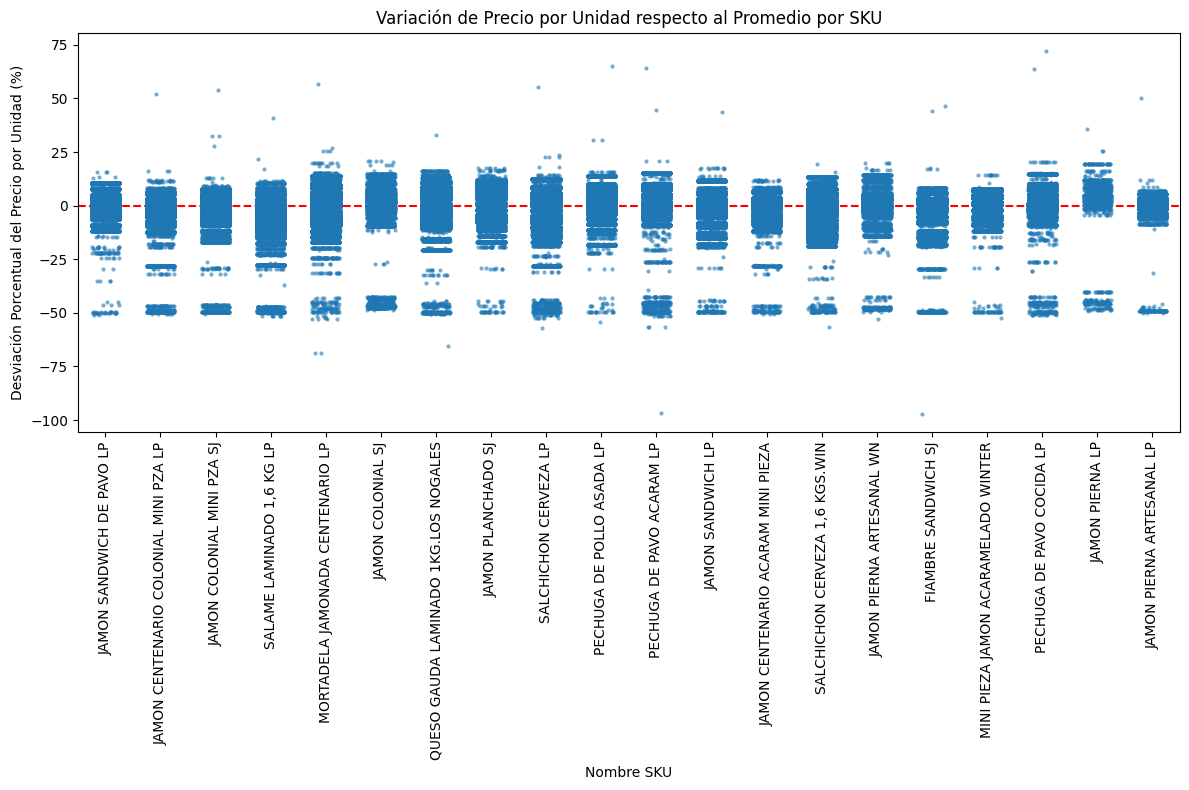

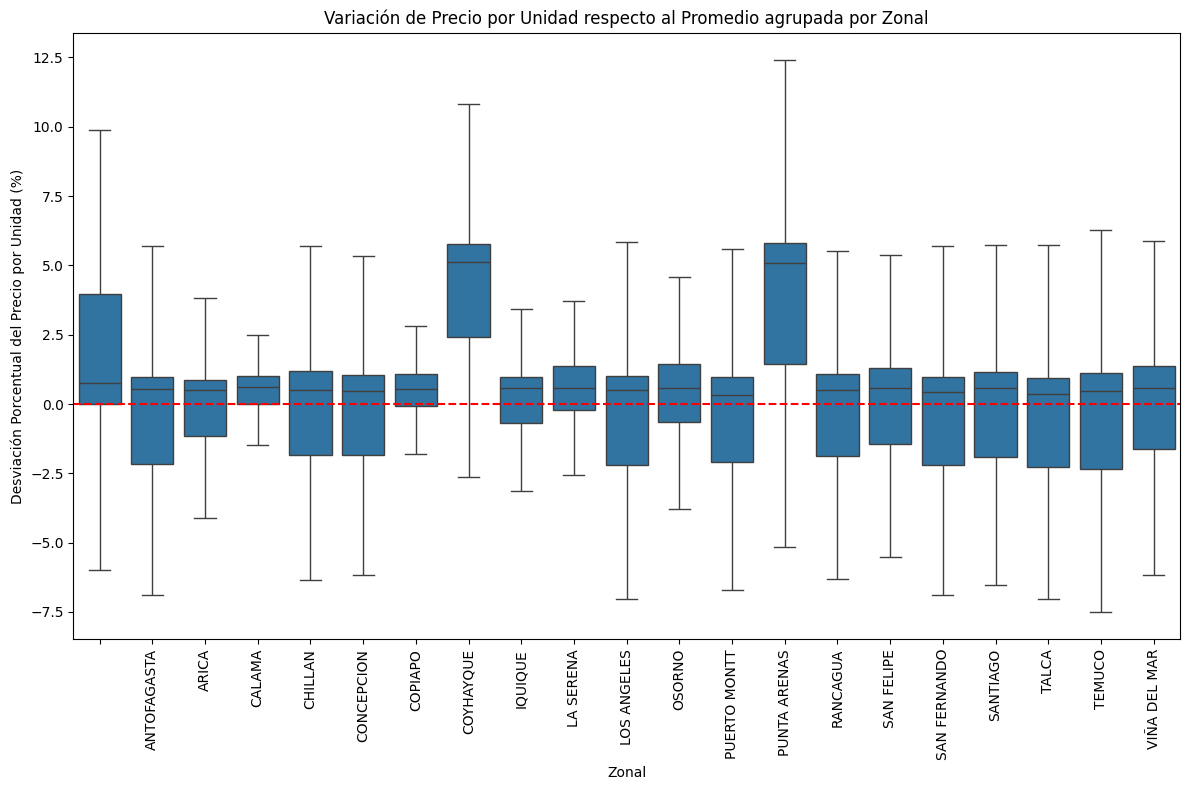

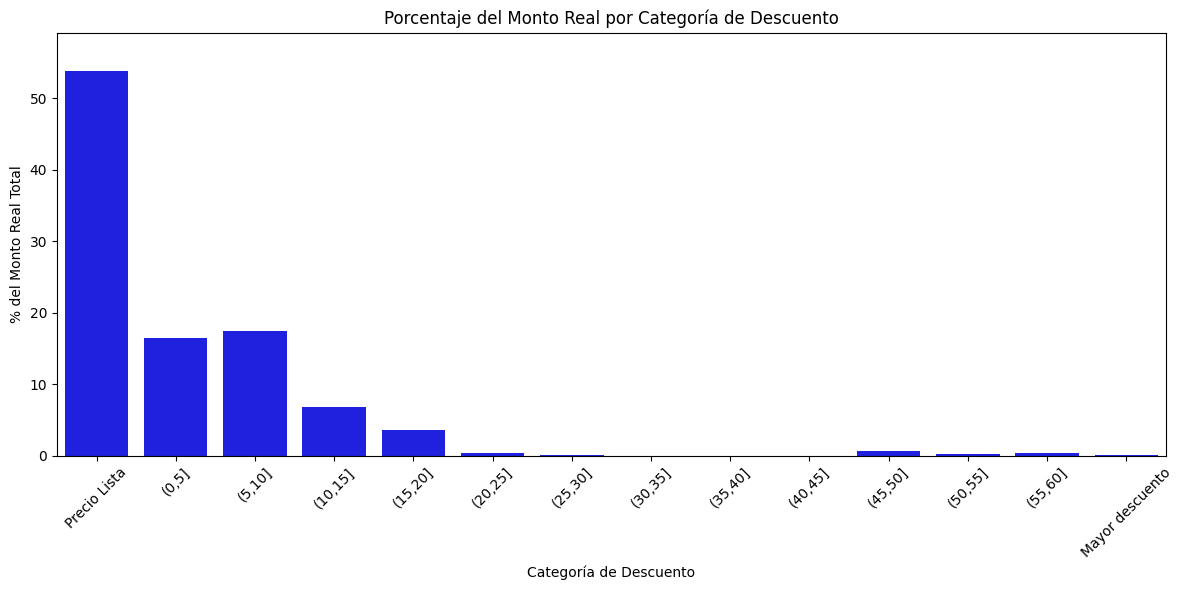

In [32]:
graficar_dispersion_sku(ventas, tabla_sku)
graficar_dispersion_geografia(ventas, geo_col="zonal")
graficar_buckets_descuento(ventas)


## 3.2 Ejemplo filtrando canal


<Axes: title={'center': 'Porcentaje del Monto Real por Categoría de Descuento'}, xlabel='Categoría de Descuento', ylabel='% del Monto Real Total'>

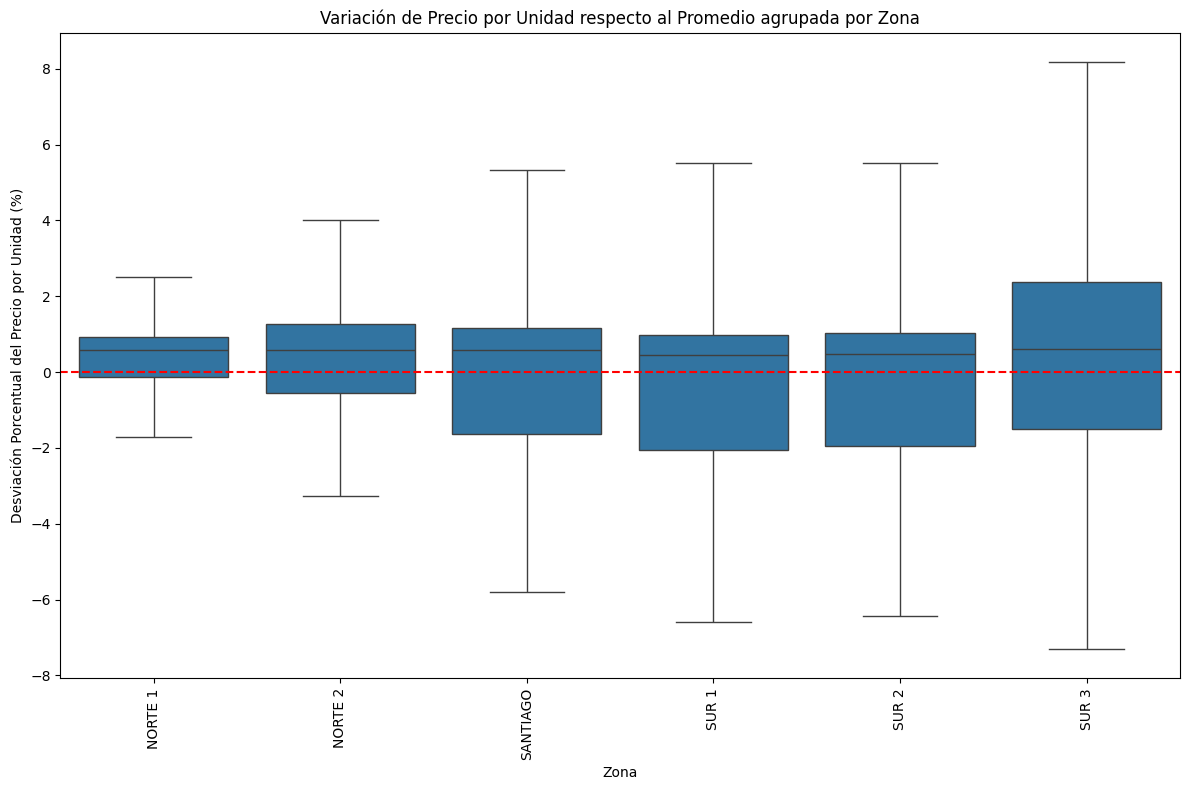

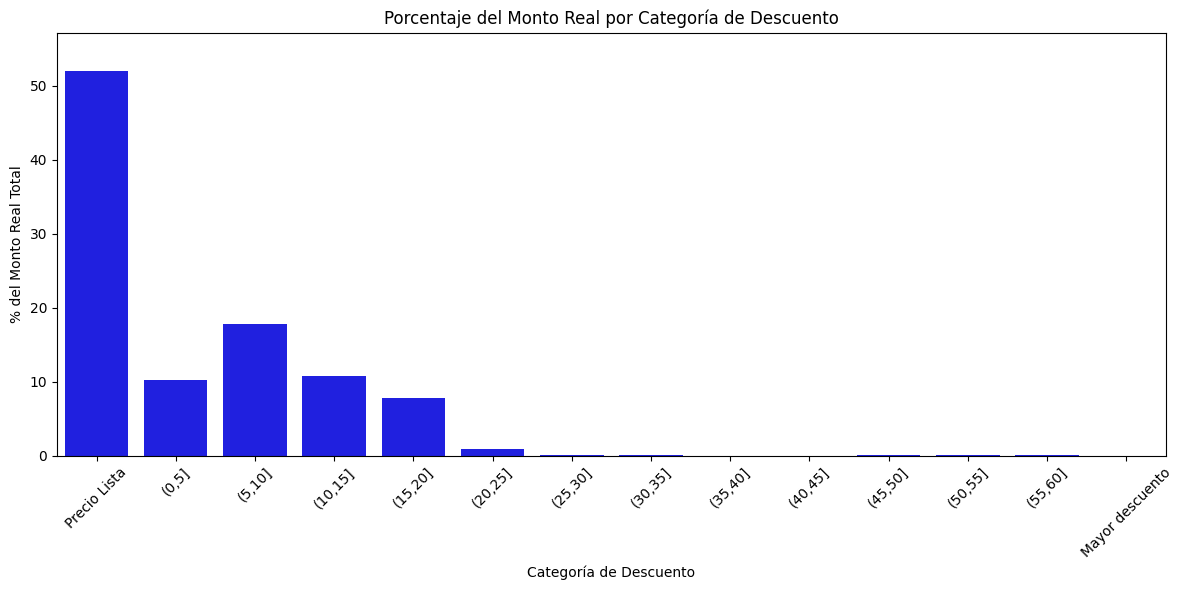

In [33]:
canal_ejemplo = (
    ventas["cod_canal_comercial"]
    .dropna()
    .value_counts()
    .head(1)
    .index
    .tolist()
)

graficar_dispersion_geografia(
    ventas,
    geo_col="zona",
    canales=canal_ejemplo,
)

graficar_buckets_descuento(
    ventas,
    canales=canal_ejemplo,
    anios=[2026],
    meses=[1, 2, 3],
)


## 3.3 Ejemplo filtrando SKU


<Axes: title={'center': 'Monto Real Total por Categoría de Descuento'}, xlabel='Categoría de Descuento', ylabel='Monto Real Total'>

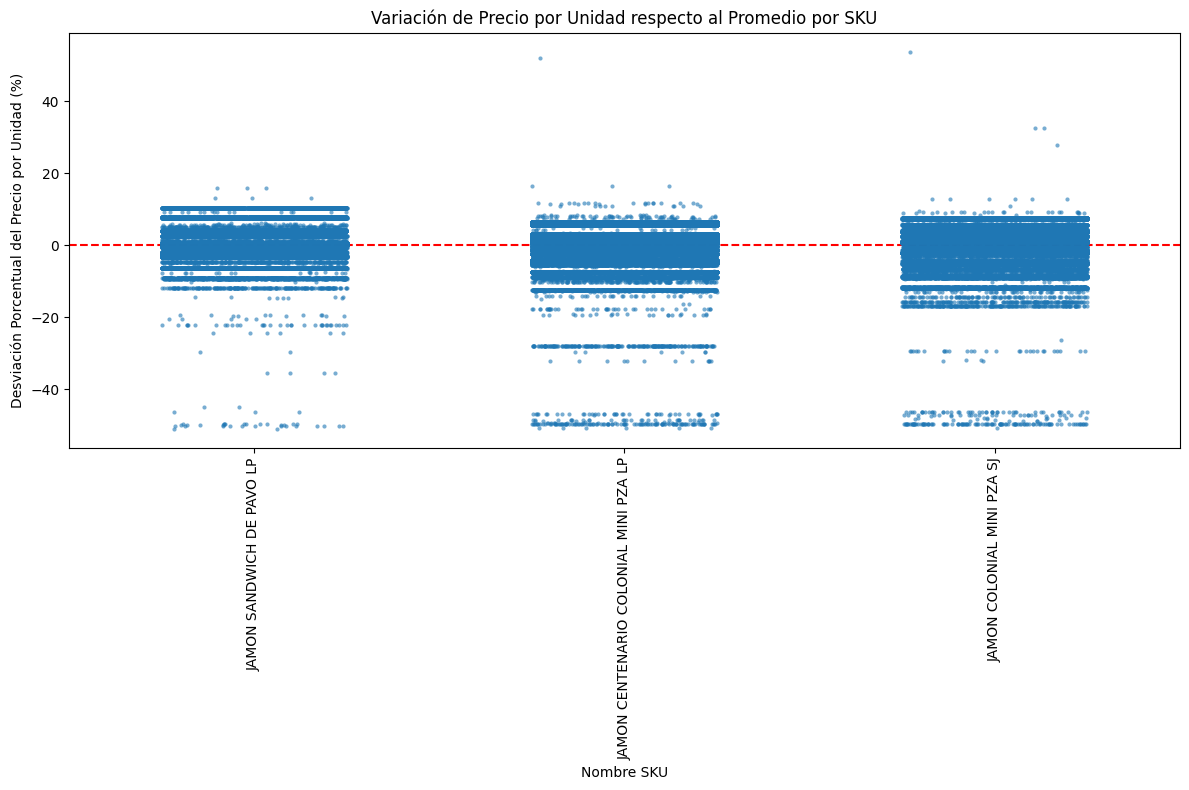

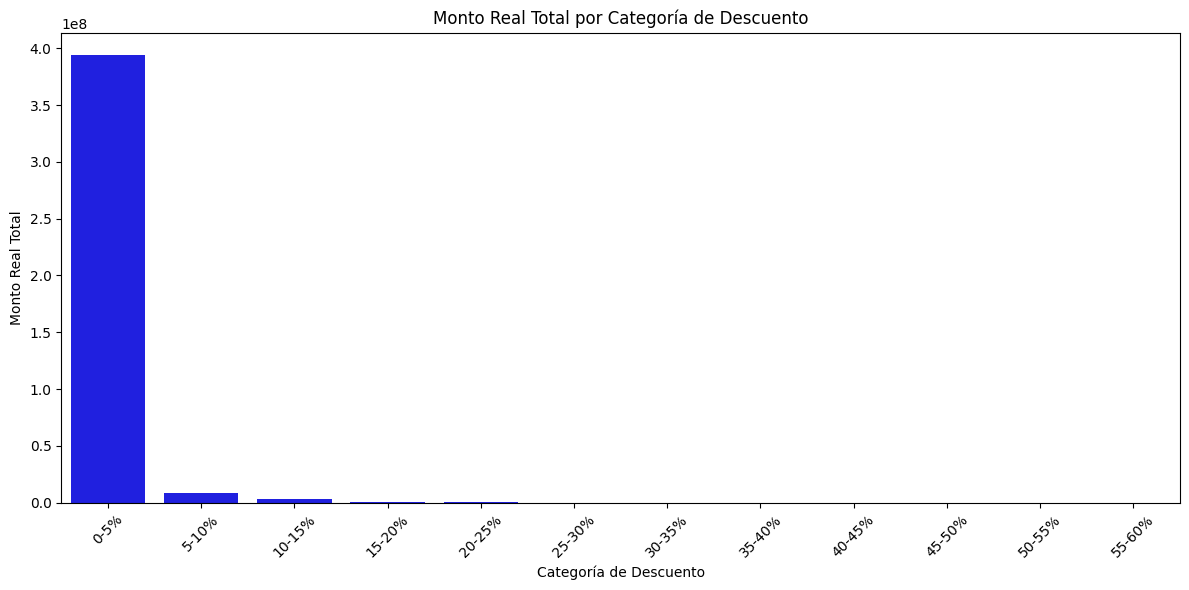

In [34]:
skus_ejemplo = (
    tabla_sku.sort_values("desviacion_por_unidad_por_ingreso", ascending=False)
    .head(3)["cod_sku"]
    .tolist()
)

graficar_dispersion_sku(
    ventas,
    tabla_sku,
    skus=skus_ejemplo,
    top_n=len(skus_ejemplo),
)

graficar_buckets_descuento(
    ventas,
    anios=[2025],
    meses=list(range(1, 7)),
    skus=skus_ejemplo[:1],
    incluir_precio_lista=False,
    y_col="monto_real",
)
